8_Breast_Cancer_Wisconsin

¿Quién lo creó y cómo se obtuvieron los datos?
Las muestras llegaron periódicamente a medida que el Dr. William H. Wolberg reportaba sus casos clínicos. La base de datos refleja esta agrupación cronológica de los datos. El Dr. Wolberg era cirujano en el Departamento de Cirugía General de la Universidad de Wisconsin, en el Clinical Sciences Center de Madison. Los datos se recolectaron a lo largo de varios años entre 1989 y 1991, en grupos cronológicos. El grupo 1 tiene 367 instancias (enero de 1989), grupo 2 con 70 instancias (octubre de 1989), grupo 3 con 31 instancias (febrero de 1990), y así sucesivamente, hasta un total de 699 puntos donados al repositorio el 15 de julio de 1992. Los datos se obtuvieron mediante aspiración con aguja fina (FNA) de masas mamarias, donde técnicos de laboratorio evaluaron visualmente las células extraídas y las calificaron en escalas del 1 al 10.

¿De qué trata?
Es uno de los datasets médicos más icónicos e históricos del aprendizaje automático. Representa biopsias de tumores mamarios, donde cada instancia es una muestra de tejido evaluada clínicamente, y el objetivo es determinar si el tumor es benigno o maligno. Fue fundamental en la investigación temprana sobre clasificación médica asistida por computadora.

¿Qué contiene?
Contiene 699 instancias y 9 características de tipo entero. Los 9 atributos son evaluaciones clínicas en escala del 1 al 10: Clump Thickness (grosor del cúmulo celular), Uniformity of Cell Size (uniformidad del tamaño celular), Uniformity of Cell Shape (uniformidad de la forma celular), Marginal Adhesion (adhesión marginal), Single Epithelial Cell Size (tamaño de una célula epitelial individual), Bare Nuclei (núcleos desnudos), Bland Chromatin (cromatina blanda), Normal Nucleoli (nucléolos normales) y Mitoses (mitosis). La variable de clase es 2 para benigno y 4 para maligno. Tiene 16 valores faltantes en la variable Bare Nuclei, marcados con "?".

Objetivo del modelo
Clasificación binaria: predecir si un tumor de mama es benigno (2) o maligno (4) con base en las características celulares observadas. Es un problema de alta importancia clínica, ya que un error de clasificación puede tener consecuencias graves. El dataset tiene un desbalance moderado (~65% benigno, ~35% maligno). Se esperan métricas de alta sensibilidad (recall) para no dejar pasar casos malignos. Algoritmos adecuados: SVM, Logistic Regression, Random Forest. También es ideal para practicar la imputación de los 16 valores faltantes.

In [1]:
# ============================================================
# LIBRERÍAS GENERALES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

In [2]:
# ── PASO 1: CARGA ───────────────────────────────────────────
nombres_bc = ['id','grosor_cumulo','uniformidad_tam',
              'uniformidad_forma','adhesion_marginal',
              'tam_celula_epitelial','nucleos_desnudos',
              'cromatina','nucleolos','mitosis','clase']

df_bc = pd.read_csv('Datasets/8_Breast_Cancer_Wisconsin/breast-cancer-wisconsin.data',
                     names=nombres_bc,
                     na_values='?')   # '?' pasa a NaN

print('Shape:', df_bc.shape)
print('\nNulos:')
print(df_bc.isnull().sum())
print('\nClases:')
print(df_bc['clase'].value_counts())
print('(2=Benigno, 4=Maligno)')

Shape: (699, 11)

Nulos:
id                       0
grosor_cumulo            0
uniformidad_tam          0
uniformidad_forma        0
adhesion_marginal        0
tam_celula_epitelial     0
nucleos_desnudos        16
cromatina                0
nucleolos                0
mitosis                  0
clase                    0
dtype: int64

Clases:
clase
2    458
4    241
Name: count, dtype: int64
(2=Benigno, 4=Maligno)


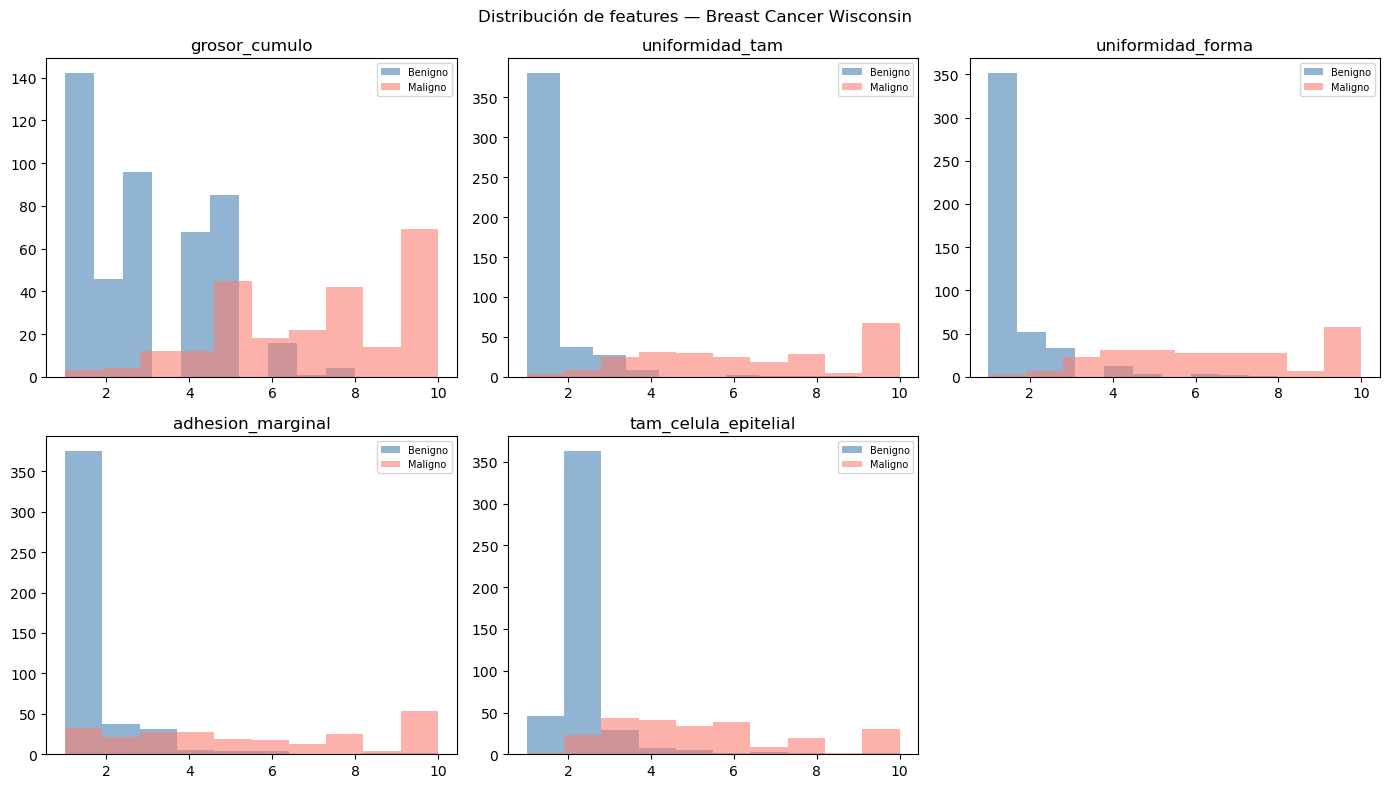

In [3]:
# ── PASO 2: GRAFICAR DISTRIBUCIONES ─────────────────────────
# Ver si las features separan bien benigno vs maligno
benigno  = df_bc[df_bc['clase']==2]
maligno  = df_bc[df_bc['clase']==4]

features_bc = ['grosor_cumulo','uniformidad_tam','uniformidad_forma',
               'adhesion_marginal','tam_celula_epitelial']

plt.figure(figsize=(14, 8))
for i, col in enumerate(features_bc):
    plt.subplot(2, 3, i+1)
    plt.hist(benigno[col].dropna(), bins=10, alpha=0.6,
                color='steelblue', label='Benigno')
    plt.hist(maligno[col].dropna(), bins=10, alpha=0.6,
                color='salmon', label='Maligno')
    plt.title(col)
    plt.legend(fontsize=7)
plt.suptitle('Distribución de features — Breast Cancer Wisconsin')
plt.tight_layout()
plt.show()

In [4]:
# ── PASO 3: LIMPIEZA ────────────────────────────────────────
# Solo 16 nulos en 'nucleos_desnudos' → reemplazar con mediana
mediana_nucleos = df_bc['nucleos_desnudos'].median()
df_bc['nucleos_desnudos'] = df_bc['nucleos_desnudos'].fillna(mediana_nucleos)
print('Nulos restantes:', df_bc.isnull().sum().sum())

Nulos restantes: 0


In [5]:
# ── PASO 4: CONSTRUIR X e y ─────────────────────────────────
# Target: 2=benigno→0, 4=maligno→1
y_bc = (df_bc['clase'] == 4).values.astype(float)

# X: todas las features excepto id y clase
cols_feat_bc = ['grosor_cumulo','uniformidad_tam','uniformidad_forma',
                'adhesion_marginal','tam_celula_epitelial',
                'nucleos_desnudos','cromatina','nucleolos','mitosis']

X_raw_bc = df_bc[cols_feat_bc].values.astype(float)
m_bc = y_bc.size

print('X shape:', X_raw_bc.shape)
print('Benigno (0):', int((y_bc==0).sum()), '| Maligno (1):', int((y_bc==1).sum()))

X shape: (699, 9)
Benigno (0): 458 | Maligno (1): 241


In [6]:
# ============================================================
# FUNCIÓN DE BALANCEO — oversampling con numpy
# ============================================================
def balancear(X, y):
    """
    Balancea un dataset desbalanceado usando OVERSAMPLING.
    
    ¿Qué hace?
    - Identifica cuántos ejemplos tiene cada clase
    - La clase con MÁS ejemplos queda igual
    - Las clases con MENOS ejemplos se repiten (con reemplazo)
      hasta tener la misma cantidad que la clase mayoritaria
    - Al final todas las clases tienen el mismo número de filas
    
    ¿Por qué oversampling y no undersampling?
    - Undersampling borra filas → perdemos información
    - Oversampling agrega filas → mantenemos toda la información original
    """
    clases = np.unique(y)
    n_max  = max(np.sum(y == c) for c in clases)   # tamaño de la clase más grande
    
    X_bal_list = []
    y_bal_list = []
    
    for c in clases:
        idx    = np.where(y == c)[0]               # índices de esta clase
        n_c    = len(idx)                           # cuántos ejemplos tiene
        
        if n_c < n_max:
            # repetir filas hasta alcanzar n_max
            extra  = n_max - n_c
            idx_extra = np.random.choice(idx, size=extra, replace=True)
            idx_final = np.concatenate([idx, idx_extra])
        else:
            idx_final = idx
        
        X_bal_list.append(X[idx_final])
        y_bal_list.append(y[idx_final])
    
    X_bal = np.concatenate(X_bal_list, axis=0)
    y_bal = np.concatenate(y_bal_list, axis=0)
    
    # Mezclar aleatoriamente para no dejar todas las clases juntas
    perm  = np.random.permutation(len(y_bal))
    return X_bal[perm], y_bal[perm]

def mostrar_balance(y, nombre, antes_despues='ANTES'):
    """Imprime cuántos ejemplos tiene cada clase."""
    clases, cuentas = np.unique(y, return_counts=True)
    print(f'  Balance {antes_despues} — {nombre}:')
    for c, n in zip(clases, cuentas):
        print(f'    Clase {int(c)}: {n} ({n/len(y)*100:.1f}%)')

np.random.seed(42)   # para reproducibilidad
print('Funciones de balanceo definidas')

Funciones de balanceo definidas


In [7]:
# ── BALANCEO ─────────────────────────────────
mostrar_balance(y_bc, 'Breast Cancer', 'ANTES')

  Balance ANTES — Breast Cancer:
    Clase 0: 458 (65.5%)
    Clase 1: 241 (34.5%)


In [8]:
def featureNormalize(X):
    """
    Normaliza las features de X.
    Para cada columna: resta la media y divide por la desviación estándar.
    
    Retorna:
      X_norm : X normalizado (mismo tamaño que X)
      mu     : media de cada columna (se guarda para normalizar datos nuevos)
      sigma  : desviación estándar de cada columna
    """
    X_norm = X.copy()
    mu     = np.mean(X, axis=0)   # media de cada columna
    sigma  = np.std(X, axis=0)    # desviación estándar de cada columna
    X_norm = (X - mu) / sigma     # estandarización Z-score
    return X_norm, mu, sigma

In [9]:
# ── PASO 5: NORMALIZAR y COLUMNA DE UNOS ────────────────────
X_norm_bc, mu_bc, sigma_bc = featureNormalize(X_raw_bc)
X_bal_bc, y_bal_bc = balancear(X_norm_bc, y_bc)
mostrar_balance(y_bal_bc, 'Breast Cancer', 'DESPUÉS')

X_bc = np.concatenate([np.ones((len(y_bal_bc), 1)), X_bal_bc], axis=1)
y_bc  = y_bal_bc

print('X_bc final:', X_bc.shape)
print(' X:', X_bc.shape, '| y:', y_bc.shape)

  Balance DESPUÉS — Breast Cancer:
    Clase 0: 458 (50.0%)
    Clase 1: 458 (50.0%)
X_bc final: (916, 10)
 X: (916, 10) | y: (916,)
